In [1]:
import cv2
import numpy as np

In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

In [34]:
from sklearn.metrics import classification_report, jaccard_score

def compute_metircs(ground_true, labels):
    ground_true = ground_true.astype(np.float32)
    labels = labels.astype(np.float32)
    ground_true /= 255
    labels /= 255
    ground_true = ground_true.astype(np.uint8)
    labels = labels.astype(np.uint8)
    y_true = ground_true.flatten()
    y_pred = labels.flatten()
    print(np.unique(labels))
    print(np.unique(ground_true))
    print(labels.shape, ground_true.shape)
    print(f'IOU: {jaccard_score(ground_true, labels,  average="macro")}')
    print(classification_report(y_true, y_pred, target_names=['contour', 'not contour']))

In [4]:
import cv2

i = 0

test_imgs = [
    '../angio-6/test_data/0.png',
    '../angio-6/test_data/1.png',
    '../angio-6/test_data/2.png',
    '../angio-6/test_data/3.png',
    '../angio-6/test_data/4.png',
    '../angio-6/test_data/5.png',
    '../angio-6/test_data/6.png',
    '../angio-6/test_data/7.png',
    '../angio-6/test_data/8.png',
    '../angio-6/test_data/9.png'
]

test_masks = [
    '../angio-6/test_data/0_mask.png',
    '../angio-6/test_data/1_mask.png',
    '../angio-6/test_data/2_mask.png',
    '../angio-6/test_data/3_mask.png',
    '../angio-6/test_data/4_mask.png',
    '../angio-6/test_data/5_mask.png',
    '../angio-6/test_data/6_mask.png',
    '../angio-6/test_data/7_mask.png',
    '../angio-6/test_data/8_mask.png',
    '../angio-6/test_data/9_mask.png'
]

test_img = test_imgs[i]
ground_true = cv2.imread(test_masks[i], cv2.IMREAD_GRAYSCALE)

hybrid

In [5]:
from model import Unet
import torch

model = Unet()
model.load_state_dict(torch.load("../resources/model.pth"))
device = 'cuda'
model.to(device)
next(model.parameters()).is_cuda

C:\Users\abram\AppData\Local\Temp\ipykernel_14024\2769380017.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../resources/model.pth"))


True

In [11]:
import cv2
from torchvision.transforms import v2
import matplotlib.pyplot as plt

def hybrid_alghorithm(path2img, threshold):
    img = cv2.imread(path2img, cv2.IMREAD_GRAYSCALE)
    tensor = v2.ToTensor()(img).unsqueeze(0).to(device)
    out = model(tensor)
    mask = out[0].cpu().detach()#.permute(1,2,0)
    probs = mask.numpy()[0]
    return np.where(probs > threshold, 255, 0).astype(np.uint8)

def hybrid(path2img, path2mask, threshold):
    plt.close('all')
    img = cv2.imread(path2img, cv2.IMREAD_GRAYSCALE)
    tensor = v2.ToTensor()(img).unsqueeze(0).to(device)
    out = model(tensor)
    mask = out[0].cpu().detach()#.permute(1,2,0)
    probs = mask.numpy()[0]
    norm = (mask.numpy()*255).astype(np.uint8)
    labels = cv2.Canny(norm, 127, 255)

    thresh = np.where(probs > threshold, 255, 0).astype(np.uint8)
    ground_true = cv2.imread(path2mask, cv2.IMREAD_GRAYSCALE)
    compute_metircs(ground_true, thresh)

    plt.figure(figsize=(12,6))

    plt.subplot(1,3,1)
    plt.imshow(img, cmap='gray')
    plt.title('original')
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(ground_true, cmap='gray')
    plt.title('mask')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(thresh, cmap='gray')
    plt.title('predicted')
    plt.axis('off')

In [12]:
from ipywidgets import interactive, FloatSlider

i = 9
output = interactive(
        hybrid,
        path2img=test_imgs[i],
        path2mask =test_masks[i],
        threshold=FloatSlider(min=0, max=1, step=0.01, value=0.5, description='Граница')
    )

display(output)

interactive(children=(Text(value='../angio-6/test_data/9.png', description='path2img'), Text(value='../angio-6…

otsu

[0 1]
[0 1]
(512, 512) (512, 512)
IOU: 0.09879249100327313
              precision    recall  f1-score   support

     contour       0.98      0.37      0.54    243017
 not contour       0.10      0.89      0.18     19127

    accuracy                           0.41    262144
   macro avg       0.54      0.63      0.36    262144
weighted avg       0.91      0.41      0.51    262144



(-0.5, 511.5, 511.5, -0.5)

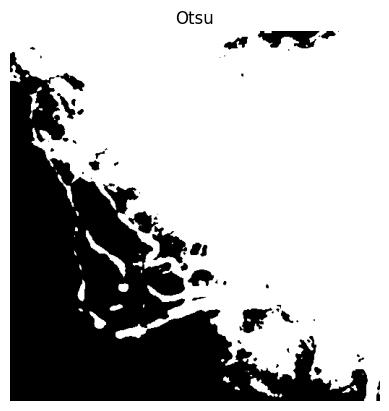

In [9]:
def otsu(path2img):
    img = cv2.imread(path2img, cv2.IMREAD_GRAYSCALE)
    blurred = cv2.GaussianBlur(img, (7, 7), 0)
    _, otsu_thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return otsu_thresh

file_path = test_img
img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
blurred = cv2.GaussianBlur(img, (7, 7), 0)
ret, otsu_thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
compute_metircs(ground_true, otsu_thresh)
plt.imshow(otsu_thresh, cmap='gray')
plt.title(f'Otsu')
plt.axis('off')

adaptive

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

def adaptive_threshold(path2img, blur, block, C):
    img = cv2.imread(path2img, cv2.IMREAD_GRAYSCALE)
    blurred = cv2.GaussianBlur(img, (blur, blur), 0)
    return cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, block, C)


# Функция для интерактивного отображения
def apply_adaptive(path2img, path2mask, blur_size=5, block_size=11, C=2, method='gaussian'):
    img = cv2.imread(path2img, cv2.IMREAD_GRAYSCALE)
    ground_true = cv2.imread(path2mask, cv2.IMREAD_GRAYSCALE)

    # Применение размытия
    if blur_size > 0:
        blurred = cv2.GaussianBlur(img, (blur_size, blur_size), 0)
    else:
        blurred = img
    
    # Корректировка block_size (должен быть нечетным)
    block_size = max(3, block_size | 1)  # Обеспечиваем нечетность
    
    # Выбор метода адаптивного порога
    if method == 'gaussian':
        adaptive_method = cv2.ADAPTIVE_THRESH_GAUSSIAN_C
    else:
        adaptive_method = cv2.ADAPTIVE_THRESH_MEAN_C
    
    # Применение адаптивного порога
    binary = cv2.adaptiveThreshold(
        blurred, 
        255, 
        adaptive_method, 
        cv2.THRESH_BINARY_INV, 
        block_size, 
        C
    )

    compute_metircs(ground_true, binary)
    
    # Отображение результатов
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(blurred, cmap='gray')
    plt.title(f'Исходное (размытие {blur_size}x{blur_size})')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(binary, cmap='gray')
    plt.title(f'Adaptive: {method}\nBlock Size: {block_size}, C: {C}')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


i = 2
interact(
    apply_adaptive,
    path2img=test_imgs[i],
    path2mask =test_masks[i],
    blur_size=IntSlider(min=0, max=20, step=1, value=5, description='Размытие:'),
    block_size=IntSlider(min=3, max=55, step=2, value=11, description='Размер блока:'),
    C=IntSlider(min=-10, max=20, step=1, value=2, description='Константа C:'),
    method=['mean', 'gaussian']
)


interactive(children=(Text(value='../angio-6/test_data/2.png', description='path2img'), Text(value='../angio-6…

<function __main__.apply_adaptive(path2img, path2mask, blur_size=5, block_size=11, C=2, method='gaussian')>

connected threshold

In [14]:
import SimpleITK as sitk
from ipywidgets import interact, IntSlider
import matplotlib.pyplot as plt


def connected_threshold(file_path, blur, low, high):
    img = sitk.ReadImage(file_path)
    img = sitk.BinomialBlur(img, blur)
    conn_thresh = sitk.ConnectedThreshold(img, seedList=[(132, 142, 96)], lower=low, upper=high)
    return sitk.GetArrayViewFromImage(conn_thresh)
    
def apply_conn_thresh(path2img, path2mask, blur, low_threshold, high_threshold):
    img = sitk.ReadImage(path2img)
    ground_true = cv2.imread(path2mask, cv2.IMREAD_GRAYSCALE)
    img = sitk.BinomialBlur(img, blur)
    conn_thresh = sitk.ConnectedThreshold(img, seedList=[(132, 142, 96)], lower=low_threshold, upper=high_threshold)

    compute_metircs(ground_true, sitk.GetArrayViewFromImage(conn_thresh))
    
    plt.figure(figsize=(12,6))
    plt.subplot(1, 2, 1)
    plt.imshow(sitk.GetArrayViewFromImage(img), cmap='gray')
    plt.title(f'Original')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(sitk.GetArrayViewFromImage(conn_thresh), cmap='gray')
    plt.title(f'Connected threshold')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

i = 0
interact(apply_conn_thresh,
    path2img = test_imgs[i],
    path2mask = test_masks[i],
    blur=IntSlider(min=0, max=9, step=1, value=1, description='Blur'),
    low_threshold=IntSlider(min=0, max=255, step=1, value=50, description='Low Threshold'),
    high_threshold=IntSlider(min=0, max=255, step=1, value=150, description='High Threshold')) #72 149

interactive(children=(Text(value='../angio-6/test_data/0.png', description='path2img'), Text(value='../angio-6…

<function __main__.apply_conn_thresh(path2img, path2mask, blur, low_threshold, high_threshold)>

FMM

In [15]:
def fmm(file_path, seedX, seedY, sigma, alpha, beta, timeThreshold, stoppingTime):
    seedPosition = (seedX, seedY)
    inputImage = sitk.ReadImage(file_path, sitk.sitkFloat32)
    smoothing = sitk.CurvatureAnisotropicDiffusionImageFilter()
    smoothing.SetTimeStep(0.125)
    smoothing.SetNumberOfIterations(5)
    smoothing.SetConductanceParameter(9.0)
    smoothingOutput = smoothing.Execute(inputImage)

    gradientMagnitude = sitk.GradientMagnitudeRecursiveGaussianImageFilter()
    gradientMagnitude.SetSigma(sigma)
    gradientMagnitudeOutput = gradientMagnitude.Execute(smoothingOutput)

    sigmoid = sitk.SigmoidImageFilter()
    sigmoid.SetOutputMinimum(0.0)
    sigmoid.SetOutputMaximum(1.0)
    sigmoid.SetAlpha(alpha)
    sigmoid.SetBeta(beta)
    sigmoidOutput = sigmoid.Execute(gradientMagnitudeOutput)

    fastMarching = sitk.FastMarchingImageFilter()

    seedValue = 0
    trialPoint = (seedPosition[0], seedPosition[1], seedValue)

    fastMarching.AddTrialPoint(trialPoint)

    fastMarching.SetStoppingValue(stoppingTime)

    fastMarchingOutput = fastMarching.Execute(sigmoidOutput)

    thresholder = sitk.BinaryThresholdImageFilter()
    thresholder.SetLowerThreshold(0.0)
    thresholder.SetUpperThreshold(timeThreshold)
    thresholder.SetOutsideValue(0)
    thresholder.SetInsideValue(255)

    result = thresholder.Execute(fastMarchingOutput)
    result = sitk.GetArrayViewFromImage(result)
    return np.where(result > 127, 255, 0).astype(np.uint8)

In [16]:
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt

def fmm_show(path2img, path2mask, seedX, seedY, sigma, alpha, beta, timeThreshold, stoppingTime):
    seedPosition = (seedX, seedY)
    inputImage = sitk.ReadImage(path2img, sitk.sitkFloat32)
    smoothing = sitk.CurvatureAnisotropicDiffusionImageFilter()
    smoothing.SetTimeStep(0.125)
    smoothing.SetNumberOfIterations(5)
    smoothing.SetConductanceParameter(9.0)
    smoothingOutput = smoothing.Execute(inputImage)

    gradientMagnitude = sitk.GradientMagnitudeRecursiveGaussianImageFilter()
    gradientMagnitude.SetSigma(sigma)
    gradientMagnitudeOutput = gradientMagnitude.Execute(smoothingOutput)

    sigmoid = sitk.SigmoidImageFilter()
    sigmoid.SetOutputMinimum(0.0)
    sigmoid.SetOutputMaximum(1.0)
    sigmoid.SetAlpha(alpha)
    sigmoid.SetBeta(beta)
    sigmoidOutput = sigmoid.Execute(gradientMagnitudeOutput)

    fastMarching = sitk.FastMarchingImageFilter()

    seedValue = 0
    trialPoint = (seedPosition[0], seedPosition[1], seedValue)

    fastMarching.AddTrialPoint(trialPoint)

    fastMarching.SetStoppingValue(stoppingTime)

    fastMarchingOutput = fastMarching.Execute(sigmoidOutput)

    thresholder = sitk.BinaryThresholdImageFilter()
    thresholder.SetLowerThreshold(0.0)
    thresholder.SetUpperThreshold(timeThreshold)
    thresholder.SetOutsideValue(0)
    thresholder.SetInsideValue(255)

    result = thresholder.Execute(fastMarchingOutput)
    result = sitk.GetArrayViewFromImage(result)
    result = np.where(result > 127, 255, 0).astype(np.uint8)
    print(np.unique(result))
    ground_true = cv2.imread(path2mask, cv2.IMREAD_GRAYSCALE)
    compute_metircs(ground_true, result)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title('Input Image')
    plt.imshow(sitk.GetArrayViewFromImage(inputImage), cmap='gray')
    plt.plot(seedX, seedY, 'r.', markersize=10)
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.title('Mask')
    plt.imshow(ground_true, cmap='gray')
    plt.plot(seedX, seedY, 'r.', markersize=10)
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.title('Result Image')
    plt.imshow(result, cmap='gray')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    

In [ ]:
from ipywidgets import interact, FloatSlider, IntSlider

i=2
interact(
    fmm_show,
    path2img=test_imgs[i],
    path2mask=test_masks[i],
    seedX=IntSlider(min=0, max=512, step=1, value=178, description='seedx'),
    seedY=IntSlider(min=0, max=512, step=1, value=232, description='seedy'),
    sigma=FloatSlider(min=0.1, max=10.0, step=0.1, value=1.0),
    alpha=FloatSlider(min=0.1, max=10.0, step=0.1, value=0.5),
    beta=FloatSlider(min=0.1, max=10.0, step=0.1, value=0.5),
    timeThreshold=FloatSlider(min=0.1, max=1000.0, step=0.1, value=100.0),
    stoppingTime=FloatSlider(min=0.1, max=1000.0, step=0.1, value=100.0)
)

interactive(children=(Text(value='../angio-6/test_data/2.png', description='path2img'), Text(value='../angio-6…

<function __main__.fmm_show(path2img, path2mask, seedX, seedY, sigma, alpha, beta, timeThreshold, stoppingTime)>

metrics

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score

def average_metric_over_data(method, params_list):
    precision = 0.0
    recall = 0.0
    f1 = 0.0
    jaccard = 0.0

    for i in range(10):
        img_path_input = test_imgs[i]
        mask_path_input = test_masks[i]
        ground_true = cv2.imread(mask_path_input, cv2.IMREAD_GRAYSCALE)
        predict = method(**params_list[i])

        y_true = ground_true.flatten()
        y_pred = predict.flatten()

        precision += precision_score(y_true, y_pred, average='macro')
        recall += recall_score(y_true, y_pred, average='macro')
        f1 += f1_score(y_true, y_pred, average='macro')
        jaccard += jaccard_score(ground_true, predict, average="macro")
    

    print(f'precision: {precision/10}')
    print(f'recall: {recall/10}')
    print(f'f1: {f1/10}')
    print(f'jaccard: {jaccard/10}')

In [18]:
hybrid_params = [
    {'path2img':test_imgs[0], 'threshold':0.16},
    {'path2img':test_imgs[1], 'threshold':0.33},
    {'path2img':test_imgs[2], 'threshold':0.33},
    {'path2img':test_imgs[3], 'threshold':0.10},
    {'path2img':test_imgs[4], 'threshold':0.16},
    {'path2img':test_imgs[5], 'threshold':0.35},
    {'path2img':test_imgs[6], 'threshold':0.65},
    {'path2img':test_imgs[7], 'threshold':0.28},
    {'path2img':test_imgs[8], 'threshold':0.11},
    {'path2img':test_imgs[9], 'threshold':0.51}
]

otsu_params = [
    {'path2img':test_imgs[0]},
    {'path2img':test_imgs[1]},
    {'path2img':test_imgs[2]},
    {'path2img':test_imgs[3]},
    {'path2img':test_imgs[4]},
    {'path2img':test_imgs[5]},
    {'path2img':test_imgs[6]},
    {'path2img':test_imgs[7]},
    {'path2img':test_imgs[8]},
    {'path2img':test_imgs[9]}
]


adaptive_params = [
    {'path2img':test_imgs[0], 'blur':11, 'block':23, 'C':2},
    {'path2img':test_imgs[1], 'blur':11, 'block':23, 'C':2},
    {'path2img':test_imgs[2], 'blur':11, 'block':23, 'C':2},
    {'path2img':test_imgs[3], 'blur':11, 'block':23, 'C':2},
    {'path2img':test_imgs[4], 'blur':11, 'block':23, 'C':2},
    {'path2img':test_imgs[5], 'blur':11, 'block':23, 'C':2},
    {'path2img':test_imgs[6], 'blur':11, 'block':23, 'C':2},
    {'path2img':test_imgs[7], 'blur':11, 'block':23, 'C':2},
    {'path2img':test_imgs[8], 'blur':11, 'block':23, 'C':2},
    {'path2img':test_imgs[9], 'blur':11, 'block':23, 'C':2}
]

connected_params = [
    {'path2img':test_imgs[0], 'blur':11, 'block':23, 'C':2},
    {'path2img':test_imgs[0], 'blur':11, 'block':23, 'C':2},
    {'path2img':test_imgs[0], 'blur':11, 'block':23, 'C':2},
    {'path2img':test_imgs[0], 'blur':11, 'block':23, 'C':2},
    {'path2img':test_imgs[0], 'blur':11, 'block':23, 'C':2},
    {'path2img':test_imgs[0], 'blur':11, 'block':23, 'C':2},
]

fmm_params = [
    {'path2img':test_imgs[0], 'seedX':153, 'seedY':215, 'sigma':1.6, 'alpha':1.1, 'beta':5.1, 'timeThreshold':648.3, 'stoppingTime':225.8}
]


In [28]:
average_metric_over_data(hybrid_alghorithm,hybrid_params)

c:\soft\miniconda\envs\VCD\lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
c:\soft\miniconda\envs\VCD\lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
c:\soft\miniconda\envs\VCD\lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn

precision: 0.9842037200927735
recall: 0.9842037200927735
f1: 0.9842037200927735
jaccard: 0.6650625124214269


In [31]:
average_metric_over_data(otsu,otsu_params)

precision: 0.5204309384127991
recall: 0.6079420290244767
f1: 0.32651075825251763
jaccard: 0.06292277479195367


In [32]:
average_metric_over_data(adaptive_threshold,adaptive_params)

c:\soft\miniconda\envs\VCD\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 in labels with no true or predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\soft\miniconda\envs\VCD\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 in labels with no true or predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


precision: 0.5956471437045157
recall: 0.7983567425327682
f1: 0.6042321814072522
jaccard: 0.1537745483703774
